In [74]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
df = pd.read_csv('~/graduate-paper-code/spe1/csv_output.csv', sep=',')
df = df[df['well_type'] == 'PROD'].reset_index(drop=True)

df = df[['N_w', 'N_o', 'coef_water', 'oil_prod']]


In [76]:
df

,N_w,N_o,coef_water,oil_prod
0,2.188532,4.174369,0.00100,45165.0
1,2.188532,3.585042,0.00010,45248.7
2,2.188532,2.237464,0.00001,45472.9
3,2.188532,3.372366,0.00010,45294.5
4,2.188532,1.511511,0.00100,45614.0
...,...,...,...,...
2356,3.729212,3.132932,0.00100,45331.3
2357,3.729212,3.160948,0.00001,45330.7
2358,3.729212,1.601287,0.00001,45589.1
2359,3.729212,1.203706,0.00010,45663.7


In [77]:
# df = df[(df['N_w'] >= 1) & (df['N_w'] <= 3.5) & (df['N_o'] >= 1) & (df['N_o'] <= 3.5)]

In [78]:
df.describe()

,N_w,N_o,coef_water,oil_prod
count,2361.000000,2361.000000,2361.000000,2361.000000
mean,3.411698,2.885521,0.000355,45377.485472
std,0.971302,1.223893,0.000441,203.841530
min,0.997730,0.800497,0.000010,45016.300000
25%,2.631501,1.792473,0.000010,45201.100000
50%,3.729212,2.883813,0.000100,45379.000000
75%,4.271859,3.932217,0.001000,45559.800000
max,4.948806,4.999405,0.001000,45731.200000


# Simple linear regression and random forest

In [79]:
X = df[['N_w', 'N_o', 'coef_water']]
y = df['oil_prod']

print('shape X - ', X.shape)
print('shape Y - ', y.shape)

# devide train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train.shape: ', X_train.shape)
print('X_train.shape: ', X_train.shape)
print('X_test.shape', X_test.shape)

# linear regression
print('LinearRegression() part')
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)


shape X -  (2361, 3)
shape Y -  (2361,)
X_train.shape:  (1888, 3)
X_train.shape:  (1888, 3)
X_test.shape (473, 3)
LinearRegression() part


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [80]:
y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear) 
r2_linear = r2_score(y_test, y_pred_linear)


print('linear reg results:')
print('linear model coeffs: ', linear_model.coef_)
print('MAE: ', mae_linear)
print('MSE: ',mse_linear)
print('RMSE: ', rmse_linear)
print('R^2: ', r2_linear)

# RandomForestRegressor
print('RandomForestRegressor')
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('random forest results:')
print('MAE: ', mean_absolute_error(y_test, y_pred_rf))
print('MSE: ',mean_squared_error(y_test, y_pred_rf))
print('RMSE: ', np.sqrt(mse_rf))
print('R^2: ', r2_score(y_test, y_pred_rf))

linear reg results:
linear model coeffs:  [-1.33489019e-01 -1.66406919e+02 -2.75126116e+02]
MAE:  6.007241208375952
MSE:  62.73862844898504
RMSE:  7.92077196042059
R^2:  0.998494453378932
RandomForestRegressor
random forest results:
MAE:  6.345856236785724
MSE:  71.11303274418657
RMSE:  8.432854365171176
R^2:  0.9982934917640259


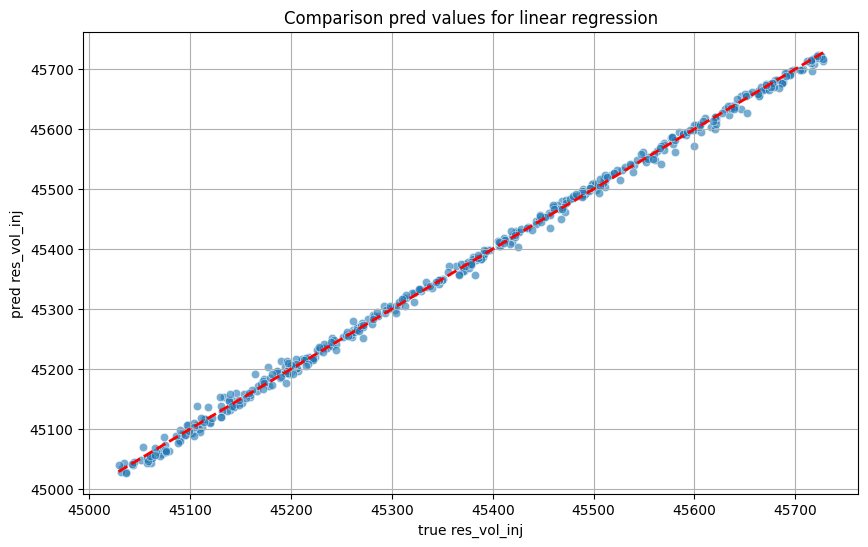

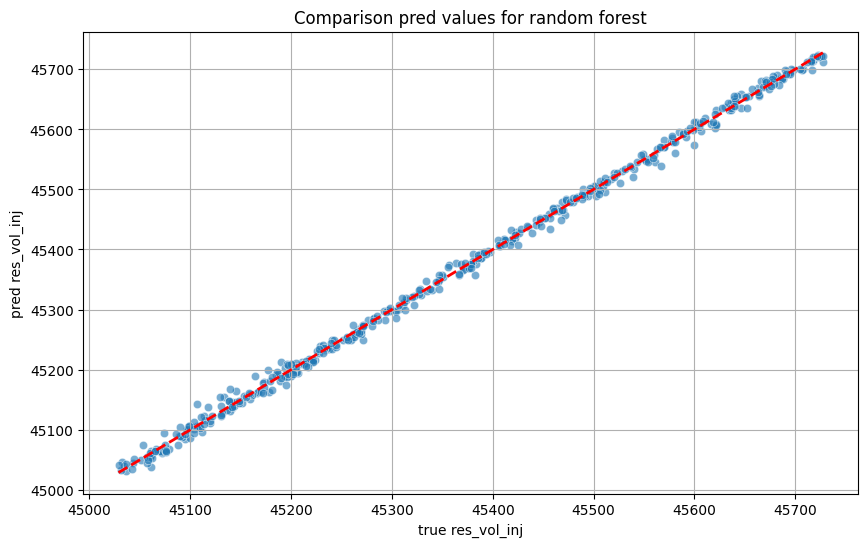

predict some values
new data: 
    N_w  N_o  coef_water
0  4.05    5      0.0001
1  8.00    3      0.0100
2  2.00    1      0.0010
predicted res_vol_inj:
[45031.673 45358.964 45695.53 ]
Features importance
N_o           0.999509
N_w           0.000385
coef_water    0.000106
dtype: float64


In [81]:
# visualizing part for linear regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("true res_vol_inj")
plt.ylabel("pred res_vol_inj")
plt.title('Comparison pred values for linear regression')
plt.grid(True)
plt.show()

# visualizing part for random forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("true res_vol_inj")
plt.ylabel("pred res_vol_inj")
plt.title('Comparison pred values for random forest')
plt.grid(True)
plt.show()

print('predict some values')
new_data_for_prediction = pd.DataFrame({
    'N_w': [4.05, 8, 2],
    'N_o': [5, 3, 1],
    'coef_water': [0.0001, 0.01, 0.001]
})
predicted_res_vol_inj = random_forest_model.predict(new_data_for_prediction)

print(f'new data: \n{new_data_for_prediction}')
print(f'predicted res_vol_inj:\n{predicted_res_vol_inj}')

print('Features importance')
feature_importances = pd.Series(random_forest_model.feature_importances_, index=X.columns)
print(feature_importances.sort_values(ascending=False))


# PCE

In [82]:
from pclearn import OrthogonalPolynomialsFeatures
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline

import time

In [83]:
X = df[['N_w', 'N_o']].values
y = df['oil_prod'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [84]:
tol_eps = 1.0e-6  # tolerance
n_cv_folds = 5
alphas = np.logspace(-5, 1, 5)
l1_ratio = np.linspace(0.05, 0.95, 10)
n_max_iter = 500

fitting_method = ElasticNetCV(l1_ratio=l1_ratio, alphas=alphas,
                              max_iter=n_max_iter, tol=tol_eps, cv=n_cv_folds,
                              fit_intercept=False, selection='random')


poly_degree = 8
n_samples_train, n_features = X_train.shape
poly_type = ['legendre'] * n_features
dlist = []
reduction = False
truncated_dim = 20
single_iter_dim = 10
niter = 500
nrand = 50

orthopoly = OrthogonalPolynomialsFeatures(
    degree=poly_degree, dlist=dlist, poly_type=poly_type,
    reduction=reduction, basis_dim=truncated_dim,
    single_iter_dim=single_iter_dim, niter=niter, nrand=nrand,
    clf=fitting_method)


In [85]:
regression_pipeline = Pipeline(steps=[
    ('orthopoly', orthopoly),
    ('fitting_method', fitting_method)])

t_start = time.time()
regression_pipeline.fit(X_train, y_train)
print('Linear problem (with PCE basis) has been solved in {:6f} seconds'.format(time.time() - t_start))

n_output_features: 45


/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.872e+10, tolerance: 3.110e+06
  model = cd_fast.enet_coordinate_descent_gram(
/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.799e+10, tolerance: 3.110e+06
  model = cd_fast.enet_coordinate_descent_gram(
/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of ite

Linear problem (with PCE basis) has been solved in 0.461162 seconds


/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.140e+08, tolerance: 3.110e+06
  model = cd_fast.enet_coordinate_descent_gram(
/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.683e+08, tolerance: 3.110e+06
  model = cd_fast.enet_coordinate_descent_gram(
/home/dmitrysavinskikh/graduate-paper-code/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of ite

Prediction over the test data in 0.473969 seconds
MSE test 181191.82642673873


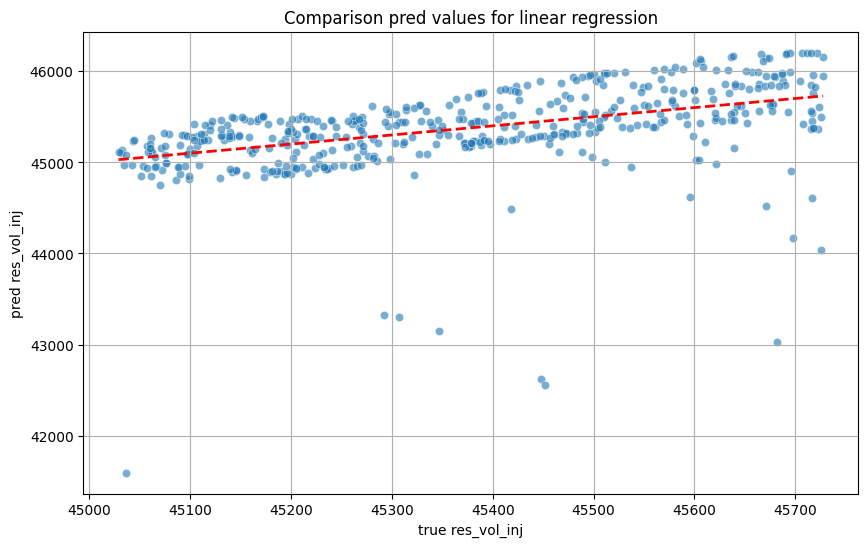

In [86]:
y_test_pred = regression_pipeline.predict(X_test)
print('Prediction over the test data in {:6f} seconds'.format(time.time() - t_start))
mse_test = mean_squared_error(y_test, y_test_pred)
print('MSE test {}'.format(mse_test))

# visualizing part for linear regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("true res_vol_inj")
plt.ylabel("pred res_vol_inj")
plt.title('Comparison pred values for linear regression')
plt.grid(True)
plt.show()